# 03 — Step 2: independent random-forest replication over Colombia

Our own implementation of the paper's **final spatial model** (ten
biophysical predictors), trained on Fagan et al. (2022) labels in Colombia,
compared with the paper on accuracy and with the authors' published map on
area and spatial pattern.

**Model.** `sklearn.ensemble.RandomForestClassifier` set to R `randomForest`
classification defaults: 500 trees, `mtry = floor(sqrt(10)) = 3`
(`max_features=3`), `nodesize = 1` (`min_samples_leaf=1`), bootstrap samples of
size n with replacement, Gini splits. Fully grown trees have pure leaves, so
`predict_proba` equals R's vote fraction. Categorical predictors (land cover,
biome) are integer-coded (sklearn has no native categorical splits in random
forests; R does).

**Sample size.** Paper: final model on 1,000,000 balanced records, validation
on 4.87 M independent balanced points. Scaled by Colombia's share of the
Fagan regrowth patches (188,921 / 4.78 M = 3.95 %): 39,523 training records.
Validation uses every point in our independent validation set.

**Areas.** Exact WGS84 area of each 30 m pixel (primary); Mollweide (sphere
R = a) and nominal 0.09 ha as sensitivity columns. Areas are estimated from the
1-in-100 systematic grid of `02b` (each grid pixel stands for 10 × 10 pixels).

**Calibration (extension; the paper does not calibrate).** The RF is trained on
50/50 samples, so its vote fractions are not probabilities at Colombia's true
regrowth prevalence π. We report expected area (i) uncalibrated, as in the
paper, and (ii) after the prior-shift correction
p′ = π·p / (π·p + (1 − π)(1 − p)), with π = exact Fagan-regrowth area / exact
area of the sampling domain (class-0 ∪ class-1 masks, 30 m, from `02b`). An
isotonic calibration fitted on one half of the validation set, weighted to
prevalence π, is a cross-check; the other half is used for evaluation
(Brier score, reliability diagram).

In [1]:
import json
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr
from healpix_geo.nested import healpix_to_lonlat, lonlat_to_healpix
from scipy import stats
from sklearn.ensemble import RandomForestClassifier
from sklearn.isotonic import IsotonicRegression
from sklearn.metrics import brier_score_loss, cohen_kappa_score, confusion_matrix

plt.style.use("seaborn-v0_8-whitegrid")

In [2]:
SMOKE = os.environ.get("SMOKE", "0") == "1"  # tiny test configuration (snakemake --config smoke=1)
CLEAN = Path("../data/clean_smoke" if SMOKE else "../data/clean")
RESULTS = Path("../results/smoke" if SMOKE else "../results")
FIGURES = Path("../figures/smoke" if SMOKE else "../figures")
DERIVED = Path("../data/derived_smoke" if SMOKE else "../data/derived")
STAGE_A = Path("../results") / "step1_authors_map_healpix_d8.nc"
N_TREES = 100 if SMOKE else 500
for d in (RESULTS, FIGURES, DERIVED):
    d.mkdir(parents=True, exist_ok=True)
SEED = 20261003
MHA = 1e10
GRID_W = 100  # 10 x 10 pixels per systematic grid point

FINAL_VARS = ["forest_density_2000", "dist_forest_2000", "ocdens", "phihox", "pc1", "pc2", "pc3", "pc4", "lc_2000", "biome"]
PRED_MAP = {"forest_density_2000": "forest_density_2018", "dist_forest_2000": "dist_forest_2018", "lc_2000": "lc_2015"}
COL_SHARE = 188_921 / 4_780_000
N_TRAIN = 2_000 if SMOKE else int(round(1_000_000 * COL_SHARE))

PAPER = dict(val_acc=0.879, oob_acc=0.878, neotropics_oa=0.865, pnr_continuous_mha=11.19, pnr_binary_mha=13.70,
             available_mha=93.78)

samples = pd.read_parquet(CLEAN / "samples.parquet")
grid = pd.read_parquet(CLEAN / "pred_grid.parquet")
sums = pd.read_csv(CLEAN / "tile_sums.csv").drop(columns="tile").sum()
meta = json.load(open(CLEAN / "features_meta.json"))
print(samples.groupby(["set", "label"]).size(), "\n", len(grid), "grid points;", meta)

set         label
train_pool  0        75990
            1        75990
validation  0        61678
            1        61678
dtype: int64 
 12161726 grid points; {'TREE_THRESHOLD': 30, 'DENSITY_RADIUS_M': 1000.0, 'DIST_CAP_M': 25000.0, 'GRID_STRIDE': 10, 'TARGET_PER_CLASS': 214809, 'RATE0': 0.0007049645526895149, 'RATE1': 0.09729694934810547, 'n_candidates': 455224, 'n_per_class': 137668, 'n_tiles': 121}


In [3]:
rng = np.random.default_rng(SEED)
pool = samples[samples.set == "train_pool"]
val = samples[samples.set == "validation"].reset_index(drop=True)
train = pd.concat([g.sample(n=min(N_TRAIN // 2, len(g)), random_state=SEED) for _, g in pool.groupby("label")])
print("training records:", len(train), train.label.value_counts().to_dict(), "| validation:", len(val))


def make_rf(max_features: int = 3, seed: int = SEED) -> RandomForestClassifier:
    return RandomForestClassifier(n_estimators=N_TREES, max_features=max_features, min_samples_leaf=1, bootstrap=True,
                                  oob_score=True, n_jobs=-1, random_state=seed)


rf = make_rf().fit(train[FINAL_VARS].to_numpy(), train.label.to_numpy())
p_val = rf.predict_proba(val[FINAL_VARS].to_numpy())[:, 1]
y_val = val.label.to_numpy()
val_acc = float(((p_val > 0.5) == y_val).mean())
cm = confusion_matrix(y_val, p_val > 0.5)
tn, fp, fn, tp = cm.ravel()
print(f"OOB accuracy {rf.oob_score_:.4f} (paper {PAPER['oob_acc']}); validation accuracy {val_acc:.4f} "
      f"(paper {PAPER['val_acc']})")
print(pd.DataFrame(cm, index=["ref 0", "ref 1"], columns=["map 0", "map 1"]))
imp = pd.Series(rf.feature_importances_, index=FINAL_VARS).sort_values(ascending=False)
print("Gini importance:\n", imp.round(4).to_string())

training records: 39522 {0: 19761, 1: 19761} | validation: 123356


OOB accuracy 0.8844 (paper 0.878); validation accuracy 0.8867 (paper 0.879)
       map 0  map 1
ref 0  56766   4912
ref 1   9066  52612
Gini importance:
 dist_forest_2000       0.2732
forest_density_2000    0.1927
phihox                 0.1142
pc2                    0.0853
pc1                    0.0780
pc3                    0.0749
pc4                    0.0743
ocdens                 0.0712
lc_2000                0.0287
biome                  0.0075


## Prevalence and calibration

In [4]:
PI = float(sums["class1_area_ell"] / (sums["class1_area_ell"] + sums["class0_area_ell"]))
print(f"prevalence pi = {sums['class1_area_ell'] / 1e4:,.0f} ha regrowth / "
      f"{(sums['class1_area_ell'] + sums['class0_area_ell']) / MHA:.3f} Mha sampling domain = {PI:.5f}")


def prior_shift(p: np.ndarray, pi: float = PI, train_prev: float = 0.5) -> np.ndarray:
    num = p * pi / train_prev
    return num / (num + (1 - p) * (1 - pi) / (1 - train_prev))


half = rng.permutation(len(val)) < len(val) // 2  # True = calibration-fit half, False = evaluation half
w_val = np.where(y_val == 1, PI, 1 - PI) / np.where(y_val == 1, (y_val == 1).mean(), (y_val == 0).mean())
iso = IsotonicRegression(out_of_bounds="clip", y_min=0, y_max=1).fit(p_val[half], y_val[half], sample_weight=w_val[half])
ev = ~half
scores = {"uncalibrated": p_val[ev], "prior_shift": prior_shift(p_val[ev]), "isotonic": iso.predict(p_val[ev])}
brier = {k: float(brier_score_loss(y_val[ev], s, sample_weight=w_val[ev])) for k, s in scores.items()}
print("Brier score on the prevalence-weighted evaluation half:", brier)

prevalence pi = 251,707 ha regrowth / 15.307 Mha sampling domain = 0.01644
Brier score on the prevalence-weighted evaluation half: {'uncalibrated': 0.0708721991620386, 'prior_shift': 0.008147165560779194, 'isotonic': 0.00806318948344988}


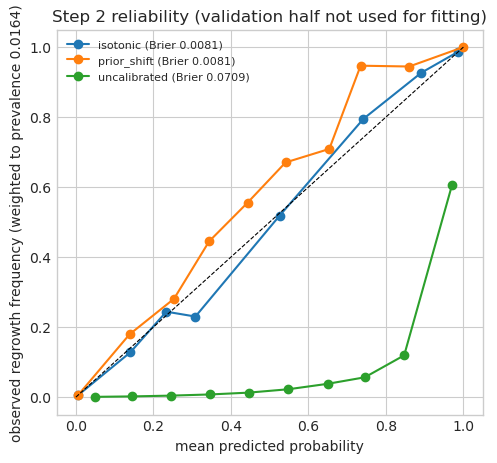

In [5]:
bins = np.linspace(0, 1, 11)
fig, ax = plt.subplots(figsize=(5.5, 5))
rel_rows = []
for k, s in scores.items():
    idx = np.clip(np.digitize(s, bins) - 1, 0, 9)
    for b in range(10):
        sel = idx == b
        if w_val[ev][sel].sum() > 0:
            rel_rows.append(dict(score=k, bin=b, mean_pred=np.average(s[sel], weights=w_val[ev][sel]),
                                 obs_freq=np.average(y_val[ev][sel], weights=w_val[ev][sel]), n=int(sel.sum())))
rel = pd.DataFrame(rel_rows)
for k, g in rel.groupby("score"):
    ax.plot(g.mean_pred, g.obs_freq, "o-", label=f"{k} (Brier {brier[k]:.4f})")
ax.plot([0, 1], [0, 1], "k--", lw=0.8)
ax.set_xlabel("mean predicted probability")
ax.set_ylabel(f"observed regrowth frequency (weighted to prevalence {PI:.4f})")
ax.set_title("Step 2 reliability (validation half not used for fitting)")
ax.legend(fontsize=8)
fig.savefig(FIGURES / "step2_reliability.png", dpi=150, bbox_inches="tight")
plt.show()
rel.to_csv(RESULTS / "step2_reliability.csv", index=False)

## Prediction on the systematic grid and areas

In [6]:
g = grid[grid.is_pred_domain].copy()
Xp = g[[PRED_MAP.get(v, v) for v in FINAL_VARS]].to_numpy()
ok = ~np.isnan(Xp).any(axis=1)
print(f"prediction-domain grid points {len(g):,}; with complete predictors {ok.sum():,} ({ok.mean():.4%})")
g = g[ok].copy()
g["p"] = rf.predict_proba(Xp[ok])[:, 1]
g["p_prior"] = prior_shift(g.p.to_numpy())
g["p_iso"] = iso.predict(g.p.to_numpy())

A = 6378137.0


def sphere_over_ellipsoid(lat: np.ndarray) -> np.ndarray:
    res = 0.00025
    f = 1 / 298.257223563
    e2 = f * (2 - f)
    e = np.sqrt(e2)
    q = lambda phi: (1 - e2) * (np.sin(phi) / (1 - e2 * np.sin(phi) ** 2)  # noqa: E731
                                - np.log((1 - e * np.sin(phi)) / (1 + e * np.sin(phi))) / (2 * e))
    top, bot = np.radians(lat + res / 2), np.radians(lat - res / 2)
    return (A**2 * (np.sin(top) - np.sin(bot))) / (A**2 / 2 * (q(top) - q(bot)))


def area_estimates(df: pd.DataFrame, weight: np.ndarray) -> dict[str, float]:
    a_ell = df.area_ell.to_numpy() * GRID_W
    y = weight * a_ell
    n = len(y)
    se = np.sqrt(n * y.var(ddof=1) * (1 - 1 / GRID_W)) if n > 1 else np.nan  # SRS approximation, conservative
    return {"ell": y.sum() / MHA, "ell_se": se / MHA,
            "sph": (y * sphere_over_ellipsoid(df.lat.to_numpy())).sum() / MHA,
            "nom": (weight * 900.0 * GRID_W).sum() / MHA}


rows = []


def add(metric: str, est: dict | float, paper: float | None = None, note: str = "") -> None:
    if isinstance(est, dict):
        rows.append(dict(metric=metric, value=est["ell"], se=est.get("ell_se"), mollweide_sphere=est["sph"],
                         nominal_009ha=est["nom"], paper_value=paper, note=note))
    else:
        rows.append(dict(metric=metric, value=est, se=None, mollweide_sphere=None, nominal_009ha=None,
                         paper_value=paper, note=note))


add("oob_accuracy", float(rf.oob_score_), PAPER["oob_acc"])
add("validation_accuracy", val_acc, PAPER["val_acc"], f"n={len(val)} balanced; paper Neotropics OA 0.865")
add("validation_users_accuracy_regrowth", float(tp / (tp + fp)), 0.92, "paper SI A1.2 global")
add("validation_producers_accuracy_regrowth", float(tp / (tp + fn)), 0.852, "paper SI A1.2 global (count based)")
add("prevalence_pi", PI, None, "Fagan regrowth area / sampling-domain area, exact 30 m")
for k, v in brier.items():
    add(f"brier_{k}", v, None, "evaluation half of validation, weighted to prevalence")
add("expected_area_uncalibrated_mha", area_estimates(g, g.p.to_numpy()), PAPER["pnr_continuous_mha"],
    "sum p x area, as in the paper")
add("expected_area_prior_shift_mha", area_estimates(g, g.p_prior.to_numpy()), None, "calibrated to prevalence")
add("expected_area_isotonic_mha", area_estimates(g, g.p_iso.to_numpy()), None, "cross-check")
add("area_p_gt_0.5_uncalibrated_mha", area_estimates(g, (g.p > 0.5).to_numpy().astype(float)), PAPER["pnr_binary_mha"])
add("area_p_gt_0.5_prior_shift_mha", area_estimates(g, (g.p_prior > 0.5).to_numpy().astype(float)), None)
add("area_p_gt_0.5_isotonic_mha", area_estimates(g, (g.p_iso > 0.5).to_numpy().astype(float)), None)
add("prediction_domain_area_mha", {"ell": sums["pred_area_ell"] / MHA, "sph": sums["pred_area_sph"] / MHA,
                                   "nom": sums["pred_n"] * 900 / MHA}, PAPER["available_mha"], "exact 30 m count")
add("study_domain_area_mha", {"ell": sums["domain_area_ell"] / MHA, "sph": sums["domain_area_sph"] / MHA,
                              "nom": sums["domain_n"] * 900 / MHA}, PAPER["available_mha"], "Colombia x biomes 1-3")
for k, lab, paper in [("expected", "authors_expected", PAPER["pnr_continuous_mha"]),
                      ("bin1", "authors_binary", PAPER["pnr_binary_mha"]),
                      ("binvalid", "authors_binary_valid", PAPER["available_mha"]),
                      ("pctvalid", "authors_continuous_valid", PAPER["available_mha"])]:
    for dom in ["domain", "pred"]:
        add(f"{lab}_in_{dom}_exact_mha", {a: sums[f"auth_{k}_{dom}_{a}"] / MHA for a in ["ell", "sph", "nom"]}, paper,
            "authors' map, exact 30 m sums within our study / prediction domain")

prediction-domain grid points 2,468,623; with complete predictors 2,456,636 (99.5144%)


## Spatial agreement with the authors' map (same 30 m pixels)

In [7]:
both = g[g.auth_pct <= 100]
r_p = stats.pearsonr(both.p, both.auth_pct / 100)[0]
r_s = stats.spearmanr(both.p, both.auth_pct)[0]
bb = g[g.auth_bin <= 1]
agree = float(((bb.p > 0.5) == (bb.auth_bin == 1)).mean())
kappa = float(cohen_kappa_score(bb.p > 0.5, bb.auth_bin == 1))
pc = g[g.auth_pct <= 100]
kappa_pct = float(cohen_kappa_score(pc.p > 0.5, pc.auth_pct > 50))
print(f"pixels with authors' continuous value: {len(both):,}  Pearson {r_p:.3f}  Spearman {r_s:.3f}")
print(f"pixels with authors' binary value: {len(bb):,}  agreement {agree:.3f}  kappa {kappa:.3f}; "
      f"kappa vs pct>50: {kappa_pct:.3f}")
print("share of our prediction-domain grid points that are NoData in the authors' continuous map:",
      f"{(g.auth_pct > 100).mean():.3f}; binary: {(g.auth_bin > 1).mean():.3f}")
add("pixel_pearson_p_vs_authors_pct", float(r_p), None, f"n={len(both)}")
add("pixel_spearman_p_vs_authors_pct", float(r_s), None)
add("pixel_binary_agreement_vs_authors_bin", agree, None, f"n={len(bb)}")
add("pixel_kappa_vs_authors_bin", kappa, None)
add("pixel_kappa_vs_authors_pct_gt50", kappa_pct, None)
add("share_pred_domain_authors_pct_nodata", float((g.auth_pct > 100).mean()), None)

pixels with authors' continuous value: 2,405,222  Pearson 0.678  Spearman 0.754
pixels with authors' binary value: 2,456,636  agreement 0.489  kappa 0.112; kappa vs pct>50: 0.130
share of our prediction-domain grid points that are NoData in the authors' continuous map: 0.021; binary: 0.000


## HEALPix depth-8 aggregation (WGS84) and cell-level agreement

In [8]:
DEPTH = 8
g["cell"] = lonlat_to_healpix(g.lon.to_numpy(), g.lat.to_numpy(), DEPTH, ellipsoid="WGS84")
grid["cell"] = lonlat_to_healpix(grid.lon.to_numpy(), grid.lat.to_numpy(), DEPTH, ellipsoid="WGS84")
aw = grid.area_ell * GRID_W
grid_auth = pd.DataFrame({
    "cell": grid.cell, "domain_area": aw,
    "auth_expected": aw * np.where(grid.auth_pct <= 100, grid.auth_pct, 0) / 100,
    "auth_bin1": aw * (grid.auth_bin == 1),
}).groupby("cell").sum()
ours = pd.DataFrame({"cell": g.cell, "pred_area": g.area_ell * GRID_W, "exp_uncal": g.p * g.area_ell * GRID_W,
                     "exp_prior": g.p_prior * g.area_ell * GRID_W,
                     "bin_uncal": (g.p > 0.5) * g.area_ell * GRID_W}).groupby("cell").sum()
cells = grid_auth.join(ours, how="left").fillna(0.0)
lon_c, lat_c = healpix_to_lonlat(cells.index.to_numpy().astype("uint64"), DEPTH, ellipsoid="WGS84")
ds = xr.Dataset({c: ("cells", cells[c].to_numpy(), {"units": "m2"}) for c in cells.columns},
                coords={"cell_ids": ("cells", cells.index.to_numpy().astype("uint64"),
                                     {"grid_name": "healpix", "level": DEPTH, "indexing_scheme": "nested",
                                      "ellipsoid": "WGS84"}),
                        "longitude": ("cells", (np.asarray(lon_c) + 180) % 360 - 180),
                        "latitude": ("cells", np.asarray(lat_c))},
                attrs={"title": "Step 2 replication vs authors' map, Colombia study domain, HEALPix depth 8",
                       "method": "1-in-100 systematic 30 m grid; areas = exact WGS84 pixel area x 100"})
ds.to_netcdf(RESULTS / "step2_healpix_d8.nc")
big = cells[cells.domain_area > 0.5 * cells.domain_area.max()]
if SMOKE and len(big) < 3:
    big = cells
r_cell = stats.pearsonr(big.exp_uncal / big.domain_area, big.auth_expected / big.domain_area)[0]
r_cell_bin = stats.pearsonr(big.bin_uncal / big.domain_area, big.auth_bin1 / big.domain_area)[0]
print(f"HEALPix d{DEPTH}: {len(big)} cells (>50 % of a full cell in the domain); "
      f"Pearson expected-area fraction {r_cell:.3f}; binary fraction {r_cell_bin:.3f}")
add("healpix_d8_pearson_expected_fraction", float(r_cell), None, f"{len(big)} cells")
add("healpix_d8_pearson_binary_fraction", float(r_cell_bin), None)

stageA = xr.open_dataset(STAGE_A)
sa = pd.Series(stageA.expected_pnr.values, index=stageA.cell_ids.values.astype("uint64"))
j = big.join(sa.rename("stageA_expected"), how="inner")
r_sa = stats.pearsonr(j.exp_uncal, j.stageA_expected)[0]
print(f"cross-check vs stage-A full-resolution authors' product (whole country, area sums): Pearson {r_sa:.3f}")
add("healpix_d8_pearson_expected_area_vs_stageA_product", float(r_sa), None, "stage A = all 30 m pixels, whole country")

HEALPix d8: 1451 cells (>50 % of a full cell in the domain); Pearson expected-area fraction 0.857; binary fraction 0.538
cross-check vs stage-A full-resolution authors' product (whole country, area sums): Pearson 0.865


In [9]:
res = pd.DataFrame(rows)
res.to_csv(RESULTS / "step2_replication_colombia.csv", index=False)
with pd.option_context("display.width", 220, "display.max_colwidth", 60):
    print(res.to_string(index=False, float_format=lambda v: f"{v:.4f}"))
g[["lon", "lat", "grow", "gcol", "area_ell", "cell", "p", "p_prior", "p_iso", "auth_pct", "auth_bin"]].to_parquet(
    DERIVED / "step2_predictions_grid.parquet")
json.dump({"pi": PI, "n_train": int(len(train)), "n_val": int(len(val))}, open(DERIVED / "step2_meta.json", "w"))

                                            metric   value     se  mollweide_sphere  nominal_009ha  paper_value                                                               note
                                      oob_accuracy  0.8844    NaN               NaN            NaN       0.8780                                                                   
                               validation_accuracy  0.8867    NaN               NaN            NaN       0.8790                       n=123356 balanced; paper Neotropics OA 0.865
                validation_users_accuracy_regrowth  0.9146    NaN               NaN            NaN       0.9200                                               paper SI A1.2 global
            validation_producers_accuracy_regrowth  0.8530    NaN               NaN            NaN       0.8520                                 paper SI A1.2 global (count based)
                                     prevalence_pi  0.0164    NaN               NaN            NaN       

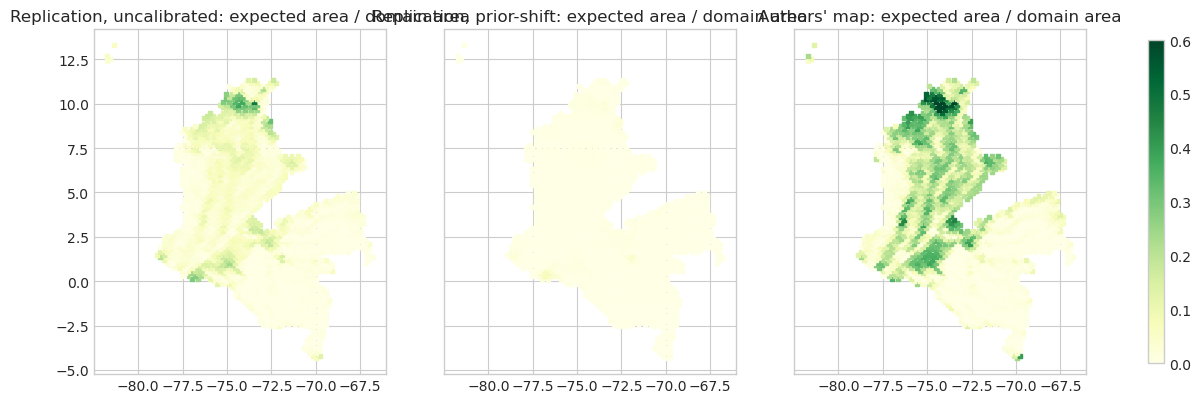

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16, 6), sharey=True)
for ax, (col_, title) in zip(axes, [("exp_uncal", "Replication, uncalibrated"), ("exp_prior", "Replication, prior-shift"),
                                    ("auth_expected", "Authors' map")]):
    sc = ax.scatter(ds.longitude, ds.latitude, c=cells[col_] / cells.domain_area, s=8, marker="s", cmap="YlGn",
                    vmin=0, vmax=0.6)
    ax.set_title(f"{title}: expected area / domain area")
    ax.set_aspect("equal")
fig.colorbar(sc, ax=axes, shrink=0.7)
fig.savefig(FIGURES / "step2_healpix_comparison.png", dpi=150, bbox_inches="tight")
plt.show()